# 1| Import our important libraries

In [22]:
# libraries for system
import os
import time
import shutil
import pathlib
import itertools



# import data handling tools
import cv2
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_style('darkgrid')
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from PIL import Image


#import DL libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam, Adamax
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Activation, Dropout, BatchNormalization
from tensorflow.keras import regularizers

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


#  Data preprocessing

In [ ]:
train_dir = '/kaggle/input/datasets/.../emotion-detection-fer/train'
filepaths = []
labels = []

folds = os.listdir(train_dir)
for fold in folds:
    foldpath = os.path.join(train_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
train_df = pd.concat([Fseries, Lseries], axis= 1)

In [7]:
train_df

,filepaths,labels
0,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
1,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
2,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
3,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
4,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
...,...,...
28704,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
28705,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
28706,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
28707,/kaggle/input/datasets/ananthu017/emotion-dete...,happy


In [ ]:
# Generate  test data paths with labels
test_dir = '/kaggle/input/datasets/.../emotion-detection-fer/test'
filepaths = []
labels = []

folds = os.listdir(test_dir)
for fold in folds:
    foldpath = os.path.join(test_dir, fold)
    filelist = os.listdir(foldpath)
    for file in filelist:
        fpath = os.path.join(foldpath, file)
        filepaths.append(fpath)
        labels.append(fold)

# Concatenate data paths with labels into one dataframe
Fseries = pd.Series(filepaths, name= 'filepaths')
Lseries = pd.Series(labels, name='labels')
test_df = pd.concat([Fseries, Lseries], axis= 1)

In [9]:
test_df

,filepaths,labels
0,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
1,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
2,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
3,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
4,/kaggle/input/datasets/ananthu017/emotion-dete...,fearful
...,...,...
7173,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
7174,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
7175,/kaggle/input/datasets/ananthu017/emotion-dete...,happy
7176,/kaggle/input/datasets/ananthu017/emotion-dete...,happy


In [11]:
# valid and test dataframe
valid_df, test_df = train_test_split(test_df,  train_size= 0.6, shuffle= True, random_state= 123)

# Image Data Generator

In [12]:
# crobed image size
batch_size = 16
img_size = (96, 96) 
channels = 3
img_shape = (img_size[0], img_size[1], channels)

tr_gen = ImageDataGenerator()
ts_gen = ImageDataGenerator()
train_gen = tr_gen.flow_from_dataframe( train_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

valid_gen = ts_gen.flow_from_dataframe( valid_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= True, batch_size= batch_size)

test_gen = ts_gen.flow_from_dataframe( test_df, x_col= 'filepaths', y_col= 'labels', target_size= img_size, class_mode= 'categorical',
                                    color_mode= 'rgb', shuffle= False, batch_size= batch_size)

Found 28709 validated image filenames belonging to 7 classes.
Found 1723 validated image filenames belonging to 7 classes.
Found 1149 validated image filenames belonging to 7 classes.


#  Showing sample from our train data

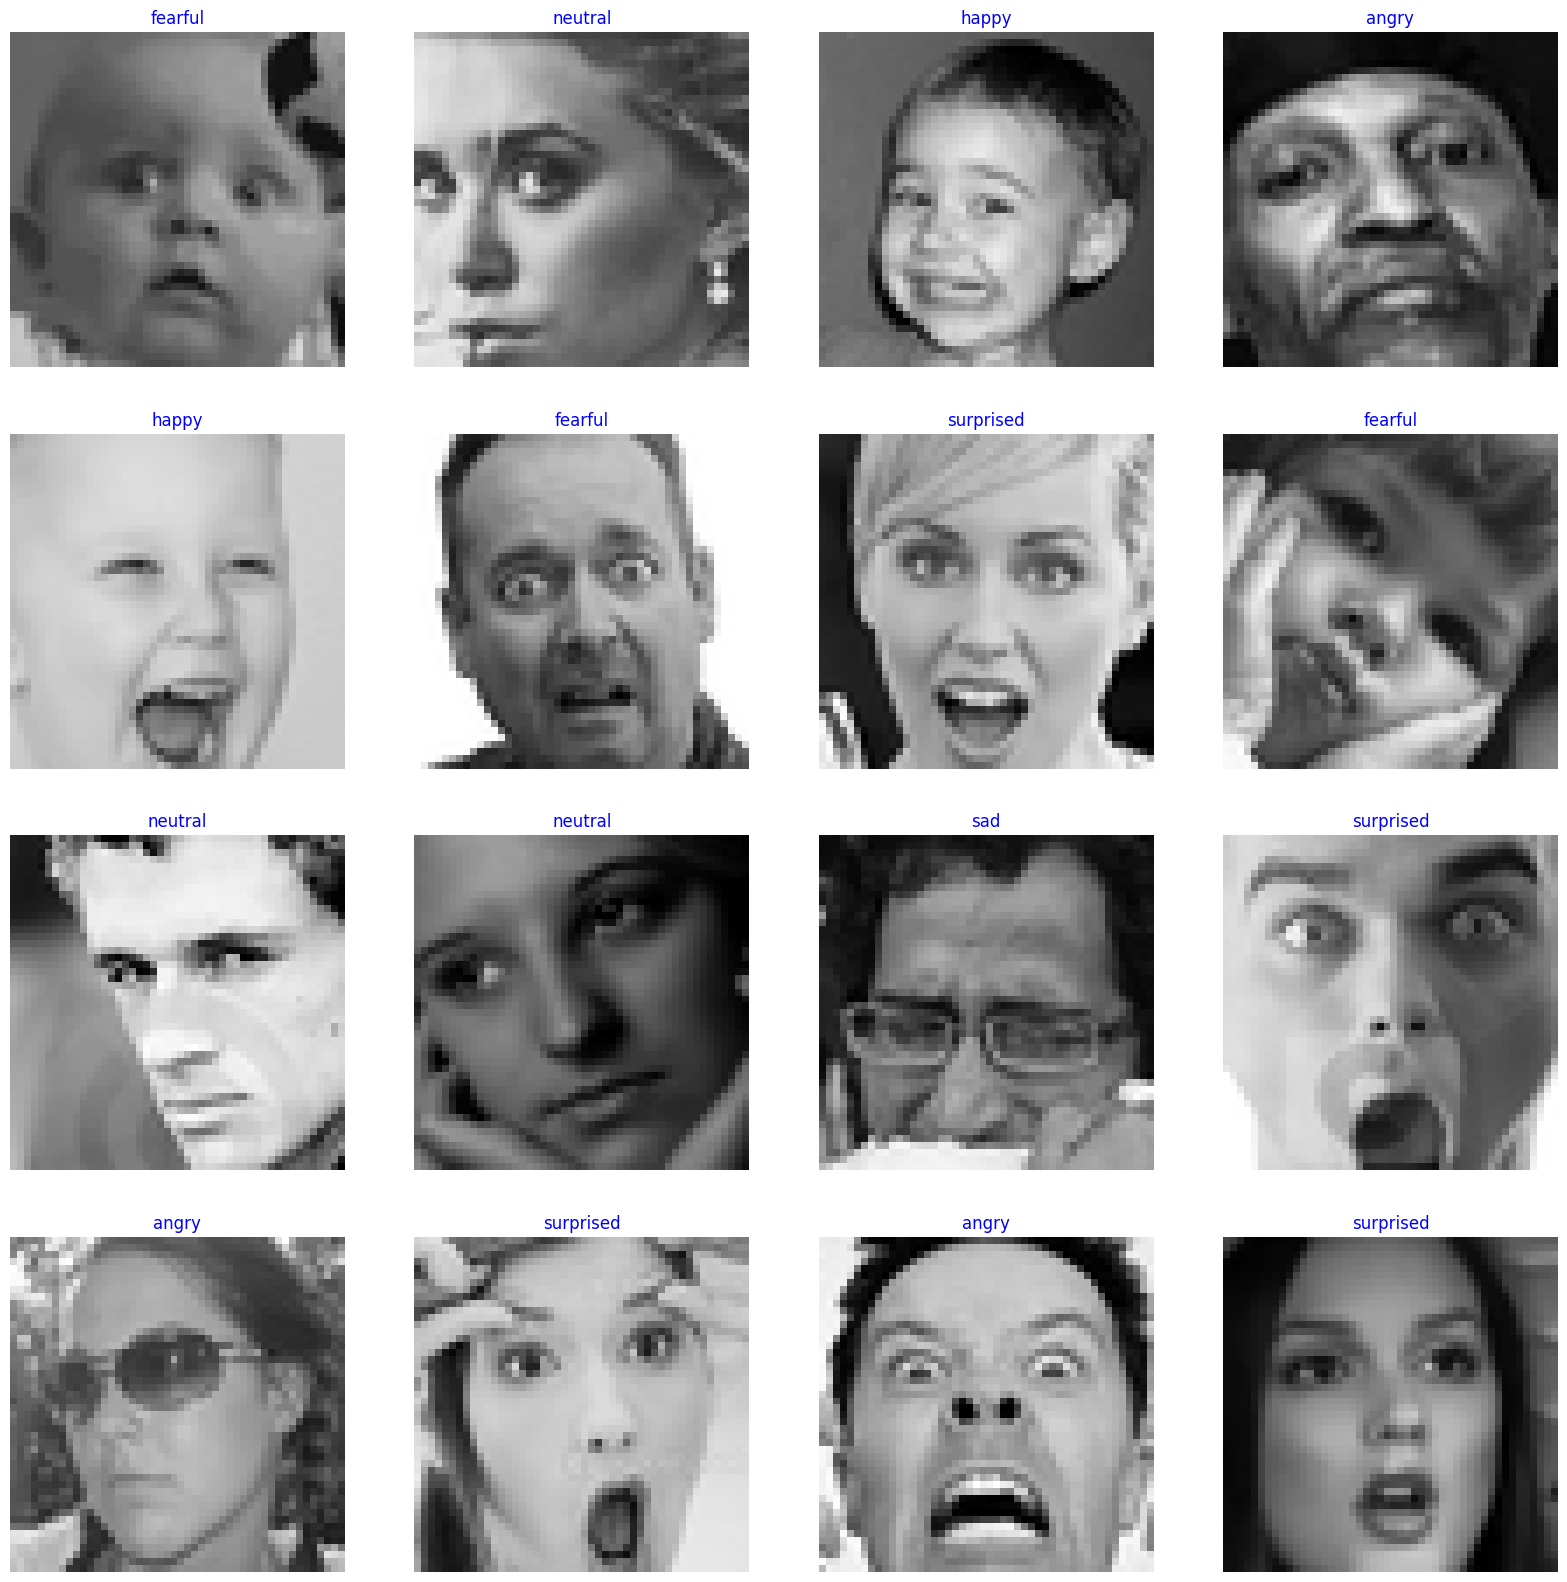

In [14]:
g_dict = train_gen.class_indices      # defines dictionary {'class': index}
classes = list(g_dict.keys())       # defines list of dictionary's kays (classes), classes names : string
images, labels = next(train_gen)      # get a batch size samples from the generator

plt.figure(figsize= (20, 20))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    image = images[i] / 255       # scales data to range (0 - 255)
    plt.imshow(image)
    index = np.argmax(labels[i])  # get image index
    class_name = classes[index]   # get class of image
    plt.title(class_name, color= 'blue', fontsize= 12)
    plt.axis('off')
plt.show()

#  Model structure - EfficientNetB7 


In [15]:
#Create Model Structure
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys()))  # 7 for FER

print("Number of classes:", class_count)
print("Class labels:", train_gen.class_indices)


Number of classes: 7
Class labels: {'angry': 0, 'disgusted': 1, 'fearful': 2, 'happy': 3, 'neutral': 4, 'sad': 5, 'surprised': 6}


In [16]:
# B3 is much better suited for FER than B7
# B7 is designed for large high-resolution images like ImageNet 600×600
base_model = tf.keras.applications.EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='max'         # global max pooling at the end
)
base_model.trainable = False  # freeze during warmup phase

I0000 00:00:1774972925.804364      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774972925.810336      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [17]:
modelEff = Sequential([
    base_model,
    BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001),  # smaller epsilon
    Dense(256,
          kernel_regularizer=regularizers.l2(l2=0.0005),   # much lighter regularization
          activity_regularizer=regularizers.l1(0.0005),    # was 0.06 — way too strong
          bias_regularizer=regularizers.l1(0.0005),
          activation='relu'),
    BatchNormalization(),                                    # add second BN for stability
    Dropout(rate=0.4, seed=123),
    Dense(128, activation='relu'),                          # extra layer helps on FER
    Dropout(rate=0.3, seed=123),
    Dense(class_count, activation='softmax', dtype='float32')
])

# Lower learning rate — 0.001 not 0.01
modelEff.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

modelEff.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       393,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,217,974 (42.79 MB)

 Trainable params: 430,855 (1.64 MB)

 Non-trainable params: 10,787,119 (41.15 MB)

In [19]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
callbacks = [
    # Reduce LR when validation accuracy plateaus
    ReduceLROnPlateau(
        monitor='val_accuracy',
        factor=0.5,          # halve the LR
        patience=3,          # wait 3 epochs before reducing
        min_lr=1e-7,
        verbose=1
    ),
    # Stop early if no improvement
    EarlyStopping(
        monitor='val_accuracy',
        patience=7,
        restore_best_weights=True,
        verbose=1
    ),
    # Save best model
    ModelCheckpoint(
        filepath='best_fer_model.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

In [20]:
print("=== Phase 1: Training top layers ===")
history_phase1 = modelEff.fit(
    x=train_gen,
    epochs=15,
    verbose=1,
    validation_data=valid_gen,
    callbacks=callbacks,
    shuffle=False
)

=== Phase 1: Training top layers ===
Epoch 1/15


I0000 00:00:1774973073.067660     146 service.cc:152] XLA service 0x788304002aa0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774973073.067700     146 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774973073.067706     146 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774973076.537307     146 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-03-31 16:04:45.042700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:04:45.177964: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:04:45.486839: E external/local_xl

1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.2936 - loss: 3.0855

2026-03-31 16:10:57.959660: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:10:58.094402: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:10:58.393676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:10:58.541209: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:10:59.327446: E external/local_xla/xla/stream_

1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 207ms/step - accuracy: 0.2936 - loss: 3.0853

2026-03-31 16:11:47.717748: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:11:47.852954: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:11:48.162249: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:11:48.309700: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 16:11:49.075663: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.39698, saving model to best_fer_model.keras
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 458s 232ms/step - accuracy: 0.2936 - loss: 3.0851 - val_accuracy: 0.3970 - val_loss: 1.9877 - learning_rate: 0.0010
Epoch 2/15
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.3643 - loss: 2.0286
Epoch 2: val_accuracy improved from 0.39698 to 0.42020, saving model to best_fer_model.keras
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 82s 46ms/step - accuracy: 0.3643 - loss: 2.0285 - val_accuracy: 0.4202 - val_loss: 1.8926 - learning_rate: 0.0010
Epoch 3/15
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3807 - loss: 1.8866
Epoch 3: val_accuracy did not improve from 0.42020
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 44s 25ms/step - accuracy: 0.3807 - loss: 1.8866 - val_accuracy: 0.4196 - val_loss: 1.8630 - learning_rate: 0.0010
Epoch 4/15
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3976 - loss: 1.8392
Epoch 4: val_accuracy improved from 0.42020 to 0.42832, savin

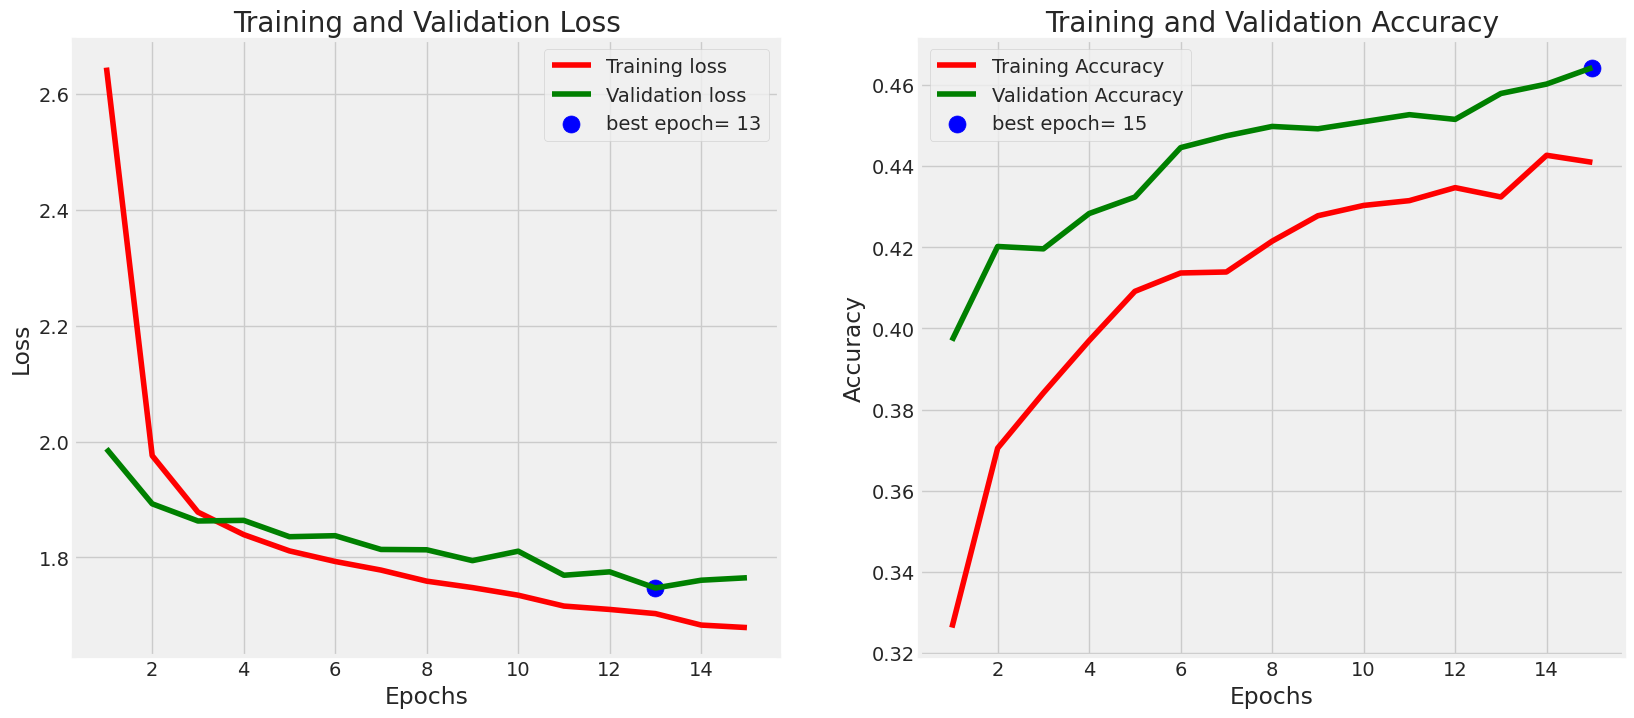

In [23]:
# Define needed variables
tr_acc = history_phase1.history['accuracy']
tr_loss = history_phase1.history['loss']
val_acc = history_phase1.history['val_accuracy']
val_loss = history_phase1.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
acc_highest = val_acc[index_acc]
Epochs = [i+1 for i in range(len(tr_acc))]
loss_label = f'best epoch= {str(index_loss + 1)}'
acc_label = f'best epoch= {str(index_acc + 1)}'
# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout
plt.show()

In [25]:
from tensorflow.keras.models import load_model

In [35]:
modelEff = load_model('/kaggle/working/best_fer_model.keras')

In [ ]:
modelEff.compile(
    optimizer=Adamax(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:


# Continue training
hist_f= modelEff.fit(
    x=train_gen,
    epochs=5,
    validation_data=valid_gen,
    callbacks=callbacks
)

Epoch 1/5
1794/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4440 - loss: 1.6292
Epoch 1: val_accuracy did not improve from 0.47127
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 122s 51ms/step - accuracy: 0.4440 - loss: 1.6292 - val_accuracy: 0.4585 - val_loss: 1.6901 - learning_rate: 0.0010
Epoch 2/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.4462 - loss: 1.6257
Epoch 2: val_accuracy did not improve from 0.47127
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 52s 29ms/step - accuracy: 0.4462 - loss: 1.6257 - val_accuracy: 0.4631 - val_loss: 1.7064 - learning_rate: 0.0010
Epoch 3/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4523 - loss: 1.6149
Epoch 3: val_accuracy did not improve from 0.47127
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 53s 30ms/step - accuracy: 0.4523 - loss: 1.6149 - val_accuracy: 0.4579 - val_loss: 1.6977 - learning_rate: 0.0010
Epoch 4/5
1795/1795 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.4581 - loss: 1.6031
Epoch 4: val_accuracy did not improve from 0.47127
1795/179

In [36]:
# base_model.trainable = True
# for layer in base_model.layers[:-30]:
#     layer.trainable = False

# Recompile with much lower LR for fine-tuning
# modelEff.compile(
#     optimizer=Adam(learning_rate=0.001),   # 100x lower than phase 1
#     loss='categorical_crossentropy',
#     metrics=['accuracy']
# )

# history_phase2 = modelEff.fit(
#     x=train_gen,
#     epochs=20,
#     verbose=1,
#     validation_data=valid_gen,
#     callbacks=callbacks,
#     shuffle=False
# )

# Evaluate the model

In [37]:
ts_length = len(test_df)
test_batch_size = max(sorted([ts_length // n for n in range(1, ts_length + 1) if ts_length%n == 0 and ts_length/n <= 80]))
test_steps = ts_length // test_batch_size

train_score = modelEff.evaluate(train_gen, steps= test_steps, verbose= 1)
valid_score = modelEff.evaluate(valid_gen, steps= test_steps, verbose= 1)
test_score = modelEff.evaluate(test_gen, steps= test_steps, verbose= 1)

print("Train Loss: ", train_score[0])
print("Train Accuracy: ", train_score[1])
print('-' * 20)
print("Validation Loss: ", valid_score[0])
print("Validation Accuracy: ", valid_score[1])
print('-' * 20)
print("Test Loss: ", test_score[0])
print("Test Accuracy: ", test_score[1])

383/383 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - accuracy: 0.5362 - loss: 1.4891
383/383 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.4736 - loss: 1.7434 
 71/383 ━━━━━━━━━━━━━━━━━━━━ 44s 143ms/step - accuracy: 0.4773 - loss: 1.6738

2026-03-31 17:19:11.707648: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 17:19:11.843718: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 17:19:12.159322: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 17:19:12.306830: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-31 17:19:13.081144: E external/local_xla/xla/stream_

383/383 ━━━━━━━━━━━━━━━━━━━━ 23s 61ms/step - accuracy: 0.4720 - loss: 1.6805  
Train Loss:  1.4853166341781616
Train Accuracy:  0.5347585082054138
--------------------
Validation Loss:  1.7458630800247192
Validation Accuracy:  0.4712710380554199
--------------------
Test Loss:  1.682053565979004
Test Accuracy:  0.47084420919418335


# Predictions

# confusion matrix and classification report

72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 42ms/step


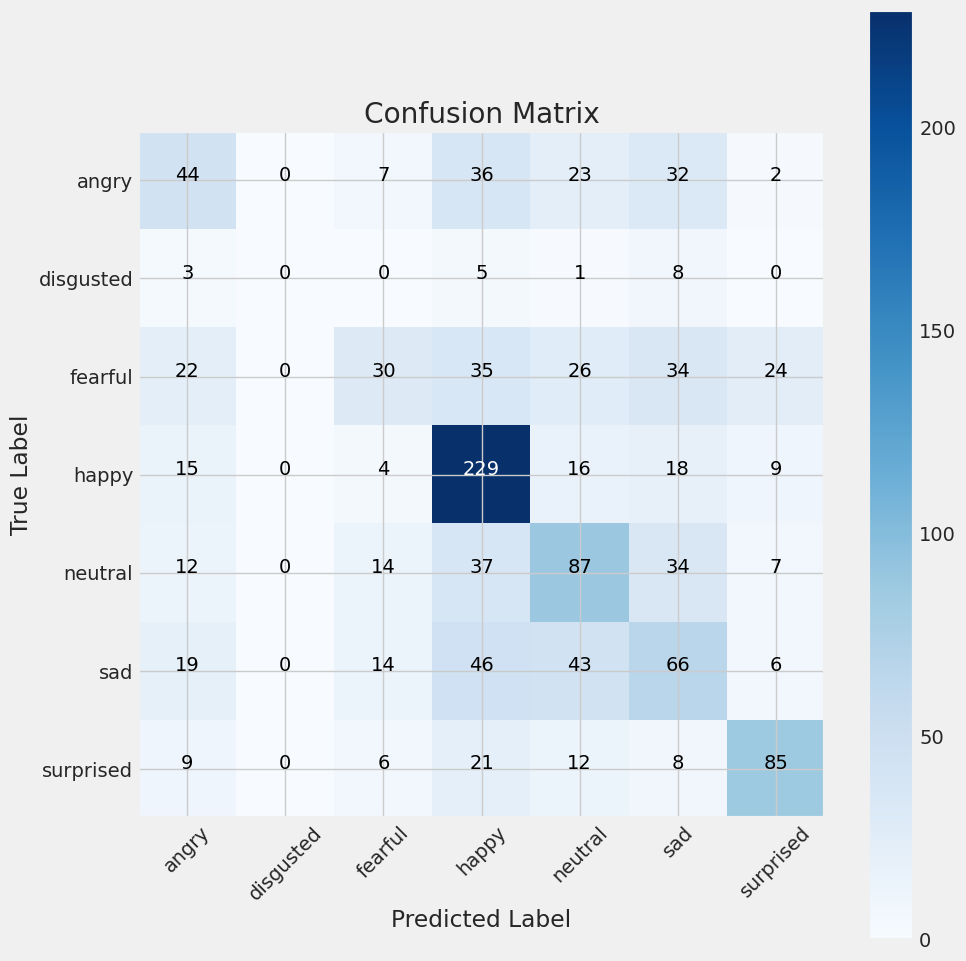

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import confusion_matrix

# Class labels
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Predictions (probabilities → class indices)
y_pred_probs = modelEff.predict(test_gen)
y_pred = np.argmax(y_pred_probs, axis=1)

# True labels
y_true = test_gen.classes

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(10, 10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

# Text annotations
thresh = cm.max() / 2.0
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(
        j, i, cm[i, j],
        horizontalalignment='center',
        color='white' if cm[i, j] > thresh else 'black'
    )

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [20]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

       angry       0.62      0.56      0.58       144
   disgusted       0.83      0.59      0.69        17
     fearful       0.64      0.54      0.59       171
       happy       0.90      0.85      0.87       291
     neutral       0.68      0.61      0.64       191
         sad       0.48      0.65      0.55       194
   surprised       0.79      0.86      0.82       141

    accuracy                           0.69      1149
   macro avg       0.71      0.66      0.68      1149
weighted avg       0.70      0.69      0.69      1149



In [22]:
modelEff.save("modelEFF.h5")

In [ ]:
loaded_model = tf.keras.models.load_model('modelEFF.h5', compile=False)
loaded_model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

1/1 [==============================] - 0s 42ms/step
happy


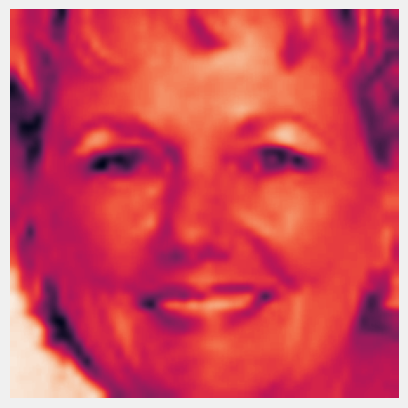

In [27]:
image_path = '/kaggle/input/emotion-detection-fer/test/happy/im1002.png'
image = Image.open(image_path)

# Preprocess the image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Make predictions
predictions = loaded_model.predict(img_array)
class_labels = classes
score = tf.nn.softmax(predictions[0])
print(f"{class_labels[tf.argmax(score)]}")
plt.imshow(img)
plt.grid("off")
plt.axis("off")
plt.show()

1/1 [==============================] - 0s 42ms/step
surprised


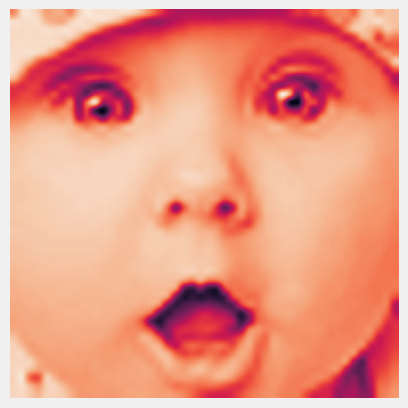

In [29]:
image_path2 = '/kaggle/input/emotion-detection-fer/test/surprised/im1.png'
image = Image.open(image_path2)

# Preprocess the image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Make predictions
predictions = loaded_model.predict(img_array)
class_labels = classes
score = tf.nn.softmax(predictions[0])
print(f"{class_labels[tf.argmax(score)]}")
plt.imshow(img)
plt.grid("off")
plt.axis("off")
plt.show()

# VGG Model

In [30]:
#Create Model Structure
img_size = (224, 224)
channels = 3
img_shape = (img_size[0], img_size[1], channels)
class_count = len(list(train_gen.class_indices.keys())) # to define number of classes in dense layer

# create pre-trained model (you can built on pretrained model such as :  efficientnet, VGG , Resnet )
# we will use efficientnetb3 from EfficientNet family.
base_model = tf.keras.applications.VGG16(include_top= False, weights= "imagenet", input_shape= img_shape, pooling= 'max')
# base_model.trainable = False
modelVGG = Sequential([
    base_model,
    BatchNormalization(axis= -1, momentum= 0.99, epsilon= 0.001),
    Dense(256, kernel_regularizer= regularizers.l2(l= 0.016), activity_regularizer= regularizers.l1(0.006),
                bias_regularizer= regularizers.l1(0.006), activation= 'relu'),
    Dropout(rate= 0.45, seed= 123),
    Dense(class_count, activation= 'softmax')
])

modelVGG.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

modelVGG.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 512)               14714688  
                                                                 
 batch_normalization_1 (Bat  (None, 512)               2048      
 chNormalization)                                                
                                                                 
 dense_2 (Dense)             (None, 256)               131328    
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_3 (Dense)             (None, 7)                 1799      
                                                                 
Total params: 14849863 (56.65 MB)
Trainable params: 148

In [31]:
batch_size = 20   # set batch size for training
epochs =  5  # number of all epochs in training

historyVGG = modelEff.fit(x= train_gen, epochs= epochs, verbose= 1, validation_data= valid_gen, 
                    validation_steps= None, shuffle= False)

Epoch 1/5
1795/1795 [==============================] - 1511s 842ms/step - loss: 0.7569 - accuracy: 0.8204 - val_loss: 1.2402 - val_accuracy: 0.6582
Epoch 2/5
1795/1795 [==============================] - 1510s 841ms/step - loss: 0.6569 - accuracy: 0.8601 - val_loss: 1.3261 - val_accuracy: 0.6640
Epoch 3/5
1795/1795 [==============================] - 1510s 841ms/step - loss: 0.5093 - accuracy: 0.9058 - val_loss: 1.3253 - val_accuracy: 0.6593
Epoch 4/5
1795/1795 [==============================] - 1509s 841ms/step - loss: 0.4410 - accuracy: 0.9216 - val_loss: 1.3487 - val_accuracy: 0.6611
Epoch 5/5
1795/1795 [==============================] - 1510s 841ms/step - loss: 0.4396 - accuracy: 0.9195 - val_loss: 1.4109 - val_accuracy: 0.6721


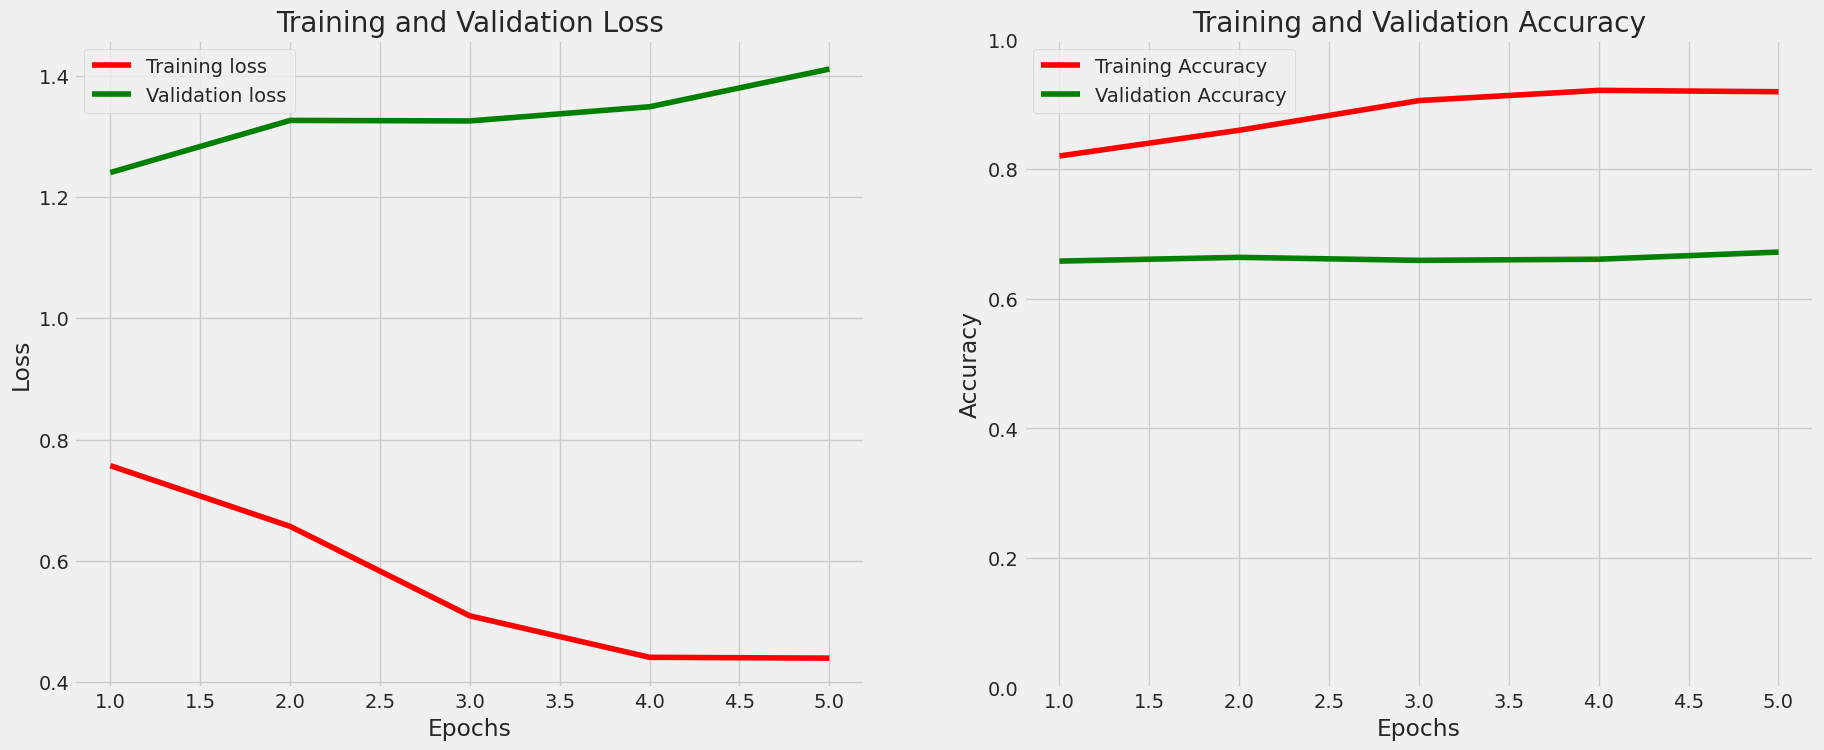

In [38]:
# Define needed variables
tr_acc = historyVGG.history['accuracy']
tr_loss = historyVGG.history['loss']
val_acc = historyVGG.history['val_accuracy']
val_loss = historyVGG.history['val_loss']
index_loss = np.argmin(val_loss)
val_lowest = val_loss[index_loss]
index_acc = np.argmax(val_acc)
#acc_highest = val_acc[index_acc]
#Epochs = [i+1 for i in range(len(tr_acc))]
#loss_label = f'best epoch= {str(index_loss + 1)}'
#acc_label = f'best epoch= {str(index_acc + 1)}'
# Plot training history
plt.figure(figsize= (20, 8))
plt.style.use('fivethirtyeight')
plt.subplot(1, 2, 1)
plt.plot(Epochs, tr_loss, 'r', label= 'Training loss')
plt.plot(Epochs, val_loss, 'g', label= 'Validation loss')
#plt.scatter(index_loss + 1, val_lowest, s= 150, c= 'blue', label= loss_label)
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(Epochs, tr_acc, 'r', label= 'Training Accuracy')
plt.plot(Epochs, val_acc, 'g', label= 'Validation Accuracy')
#plt.scatter(index_acc + 1 , acc_highest, s= 150, c= 'blue', label= acc_label)
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend()
plt.tight_layout
plt.show()

# Predictions 

In [39]:
preds = modelVGG.predict_generator(test_gen)
y_pred = np.argmax(preds, axis=1)

# Confusion Metrics

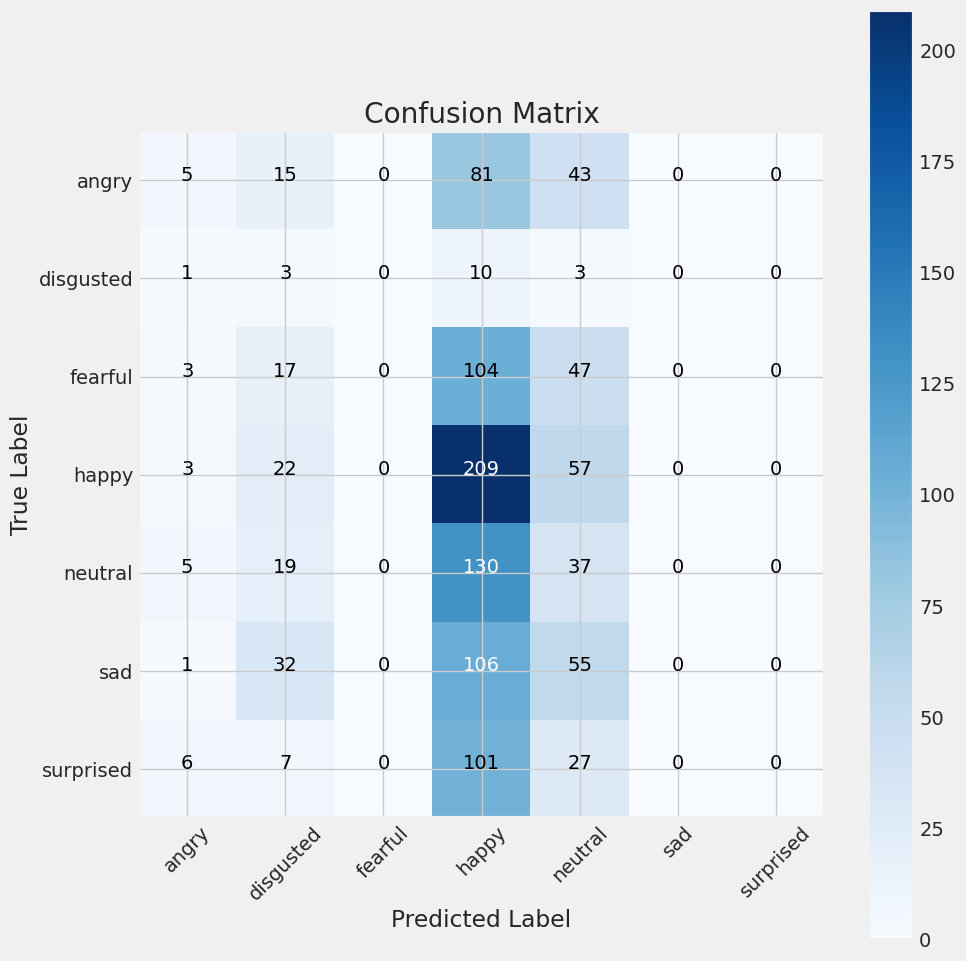

In [40]:
g_dict = test_gen.class_indices
classes = list(g_dict.keys())

# Confusion matrix
cm = confusion_matrix(test_gen.classes, y_pred)

plt.figure(figsize= (10, 10))
plt.imshow(cm, interpolation= 'nearest', cmap= plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation= 45)
plt.yticks(tick_marks, classes)
thresh = cm.max() / 2.
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, cm[i, j], horizontalalignment= 'center', color= 'white' if cm[i, j] > thresh else 'black')

plt.tight_layout()
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.show()

In [41]:
# Classification report
print(classification_report(test_gen.classes, y_pred, target_names= classes))

              precision    recall  f1-score   support

       angry       0.21      0.03      0.06       144
   disgusted       0.03      0.18      0.05        17
     fearful       0.00      0.00      0.00       171
       happy       0.28      0.72      0.41       291
     neutral       0.14      0.19      0.16       191
         sad       0.00      0.00      0.00       194
   surprised       0.00      0.00      0.00       141

    accuracy                           0.22      1149
   macro avg       0.09      0.16      0.10      1149
weighted avg       0.12      0.22      0.14      1149



In [42]:
modelEff.save("modelVGG.h5")

# Make Predictions 

In [43]:
loaded_model = tf.keras.models.load_model('/kaggle/working/modelVGG.h5', compile=False)
loaded_model.compile(Adamax(learning_rate= 0.001), loss= 'categorical_crossentropy', metrics= ['accuracy'])

1/1 [==============================] - 5s 5s/step
happy


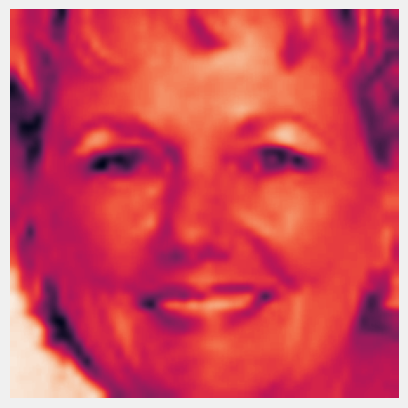

In [44]:
image_path = '/kaggle/input/emotion-detection-fer/test/happy/im1002.png'
image = Image.open(image_path)

# Preprocess the image
img = image.resize((224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)

# Make predictions
predictions = loaded_model.predict(img_array)
class_labels = classes
score = tf.nn.softmax(predictions[0])
print(f"{class_labels[tf.argmax(score)]}")
plt.imshow(img)
plt.grid("off")
plt.axis("off")
plt.show()